In [1]:
import numpy as np
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, Normalize
from matplotlib.patches import Rectangle
import xarray as xr

import cmocean
from glob import glob
import cartopy
from cartopy.crs import PlateCarree, Geodetic
import warnings

import pandas as pd
import geopandas as gpd
import seaborn as sns

warnings.simplefilter('ignore')

# Set Parameters

In [82]:
year = 2020

In [101]:
# Paths
project_folder_path = Path('/gxfs_work/geomar/smomw597/2025_copepods/')
sample_points_file_path = project_folder_path / 'output/sample_points/sample_points_moved.geojson'
trajectory_path = project_folder_path / f'output/Trajectories/{year}/'
connectivity_matrix_folder_path = project_folder_path / 'output/VoronoiConnectivity/'
figure_output_path = project_folder_path / 'Figures/connectivity_matrices/'
voronoi_polygons_moved_file_path = project_folder_path / "output/sample_points/voronoi_polygons_moved.geojson"
voronoi_polygons_original_file_path = project_folder_path / "output/sample_points/voronoi_polygons_original.geojson"
voronoi_polygons_moved = gpd.read_file(voronoi_polygons_moved_file_path)
voronoi_polygons_original = gpd.read_file(voronoi_polygons_original_file_path)

In [84]:
# Set the basic mapping parameters
suptitle_size = 20
axis_size = 16
mapsize = (16, 16)
extent = (7, 10, 53, 55)
lon_mid = np.mean(extent[:2])
lat_mid = np.mean(extent[2:])
map_projection = PlateCarree()

In [85]:
def basemap(ax, extent=extent):
    ax.set_extent(extent, PlateCarree())
    ax.add_feature(cartopy.feature.LAND)
    ax.add_feature(cartopy.feature.COASTLINE)
    ax.gridlines(draw_labels=["left", "bottom"], y_inline=False,)
    return ax

In [86]:
start_month = 6
start_day = 1
end_month = 9
end_day = 30
start_date = np.datetime64(f'{year}-{start_month:02d}-{start_day:02d}', 'D')
end_date = np.datetime64(f'{year}-{end_month:02d}-{end_day:02d}', 'D')
first_day_in_year = np.datetime64(f'{year}-01-01', 'D')

start_date_str = start_date.astype(str).replace('-','')
end_date_str = end_date.astype(str).replace('-','')

start_file = (start_date - first_day_in_year).astype(int) * 4-1
end_file = (end_date - first_day_in_year + 1).astype(int) * 4+1

In [87]:
folder_path_bsh_400 = Path('/gxfs_work/geomar/smomw400/bsh_operationalmodel_data/')
c_files_fine = sorted(folder_path_bsh_400.glob(f'c_file_fine_{year}/*'))[start_file:end_file]
current = xr.open_mfdataset(c_files_fine[0:5]).isel(layer_number=0).drop('wvel')
lon_condition = (current.lon < extent[1]) & (extent[0] < current.lon)
lat_condition = (current.lat < extent[3]) & (extent[2] < current.lat)
current = current.where(lon_condition & lat_condition, drop=True).chunk({'time': 1000, 'lat': 1000, 'lon': 1000}).compute().mean('time')
abs_current = (current.uvel**2 + current.vvel**2)**(1/2)

In [88]:
# Read and prepare the trajectory file
trajectory_file = sorted(trajectory_path.glob(f'*WH01*'))[0]
trajectory_WH01 = xr.open_zarr(trajectory_file).get(['lat','lon'])
trajectory_file = sorted(trajectory_path.glob(f'*WH02*'))[0]
trajectory_WH02 = xr.open_zarr(trajectory_file).get(['lat','lon'])
trajectory_file = sorted(trajectory_path.glob(f'*SK01*'))[0]
trajectory_SK01 = xr.open_zarr(trajectory_file).get(['lat','lon'])
trajectory_file = sorted(trajectory_path.glob(f'*SK02*'))[0]
trajectory_SK02 = xr.open_zarr(trajectory_file).get(['lat','lon'])

In [89]:
test = trajectory_WH01.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_WH01_far = trajectory_WH01.where(far_dist.broadcast_like(trajectory_WH01), drop=True)

In [90]:
test = trajectory_WH02.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_WH02_far = trajectory_WH02.where(far_dist.broadcast_like(trajectory_WH02), drop=True)

In [91]:
test = trajectory_SK01.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_SK01_far = trajectory_SK01.where(far_dist.broadcast_like(trajectory_SK01), drop=True)

In [92]:
test = trajectory_SK02.chunk({'obs': 5, 'trajectory': 182000}).isel(obs=[0,24*4*25]).compute()
far_dist = ((test.isel(obs=1).lat-test.isel(obs=0).lat)**2 + (test.isel(obs=1).lon-test.isel(obs=0).lon)**2)**(1/2) > 1
trajectory_SK02_far = trajectory_SK02.where(far_dist.broadcast_like(trajectory_SK02), drop=True)

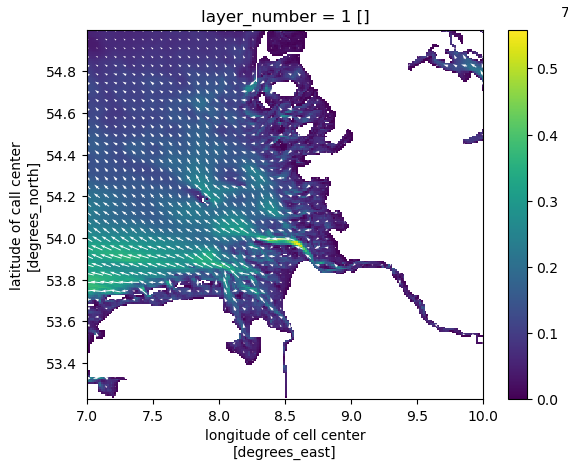

In [93]:
abs_current.plot()
current.isel(lon=slice(None, None, 5), lat=slice(None, None, 5)).plot.quiver(x='lon', y='lat', u='uvel', v='vvel', color='white')
plt.show()

In [94]:
df_WH01 = trajectory_WH01_far.to_dataframe().reset_index() #.to_crs(Geodetic())
gdf_WH01 = gpd.GeoDataFrame(df_WH01.trajectory, geometry=gpd.points_from_xy(df_WH01.lon, df_WH01.lat, crs=Geodetic()))
gdf_WH01

,trajectory,geometry
0,1878,POINT (8.15112 53.51432)
1,1878,POINT (8.15112 53.51561)
2,1878,POINT (8.15112 53.51561)
3,1878,POINT (8.15112 53.51596)
4,1878,POINT (8.15112 53.51633)
...,...,...
27835,56221,POINT EMPTY
27836,56221,POINT EMPTY
27837,56221,POINT EMPTY
27838,56221,POINT EMPTY


<Axes: >

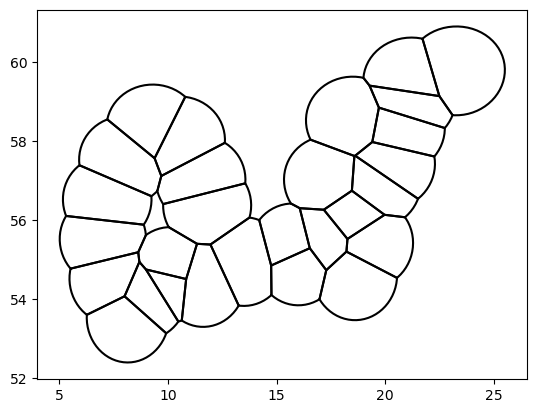

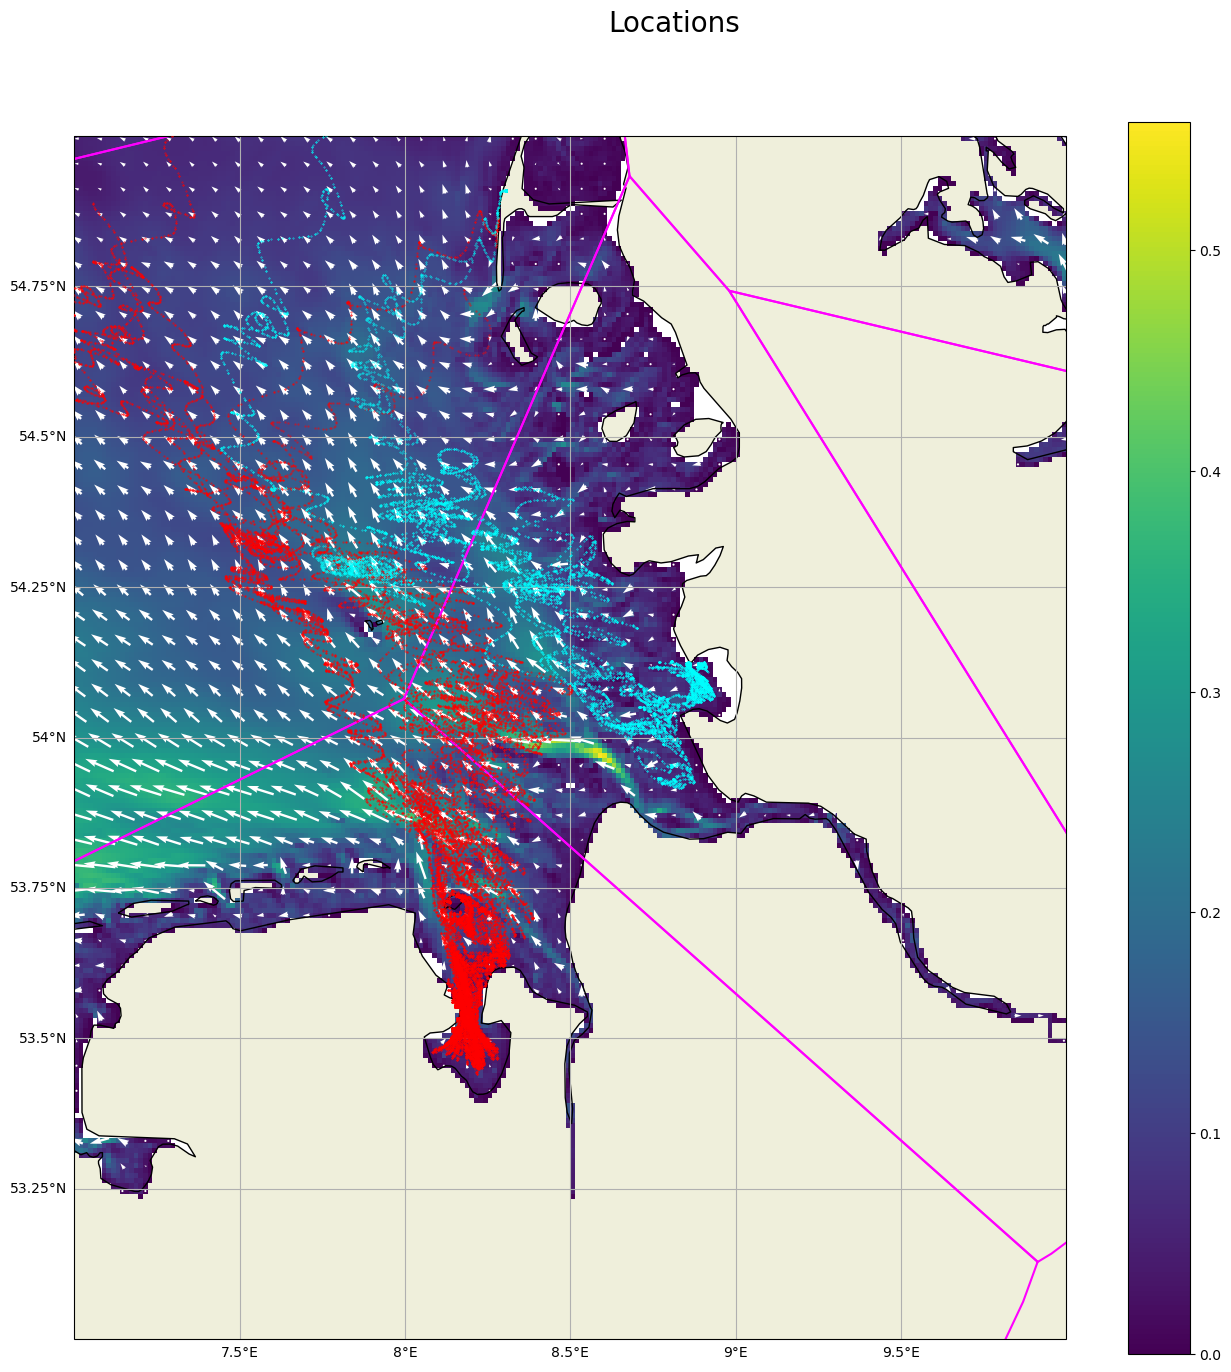

In [111]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map, extent)
abs_current.plot(ax=ax_map)
current.isel(lon=slice(None, None, 5), lat=slice(None, None, 5)).plot.quiver(x='lon', y='lat', u='uvel', v='vvel', color='white')
trajectory_WH01_far.plot.scatter(x='lon', y='lat', color='red', s=0.1, ax=ax_map, zorder=10)
trajectory_SK01_far.plot.scatter(x='lon', y='lat', color='cyan', s=0.1, ax=ax_map, zorder=10)
voronoi_polygons_original.geometry.boundary.plot(color='magenta', ax=ax_map)
plt.show()

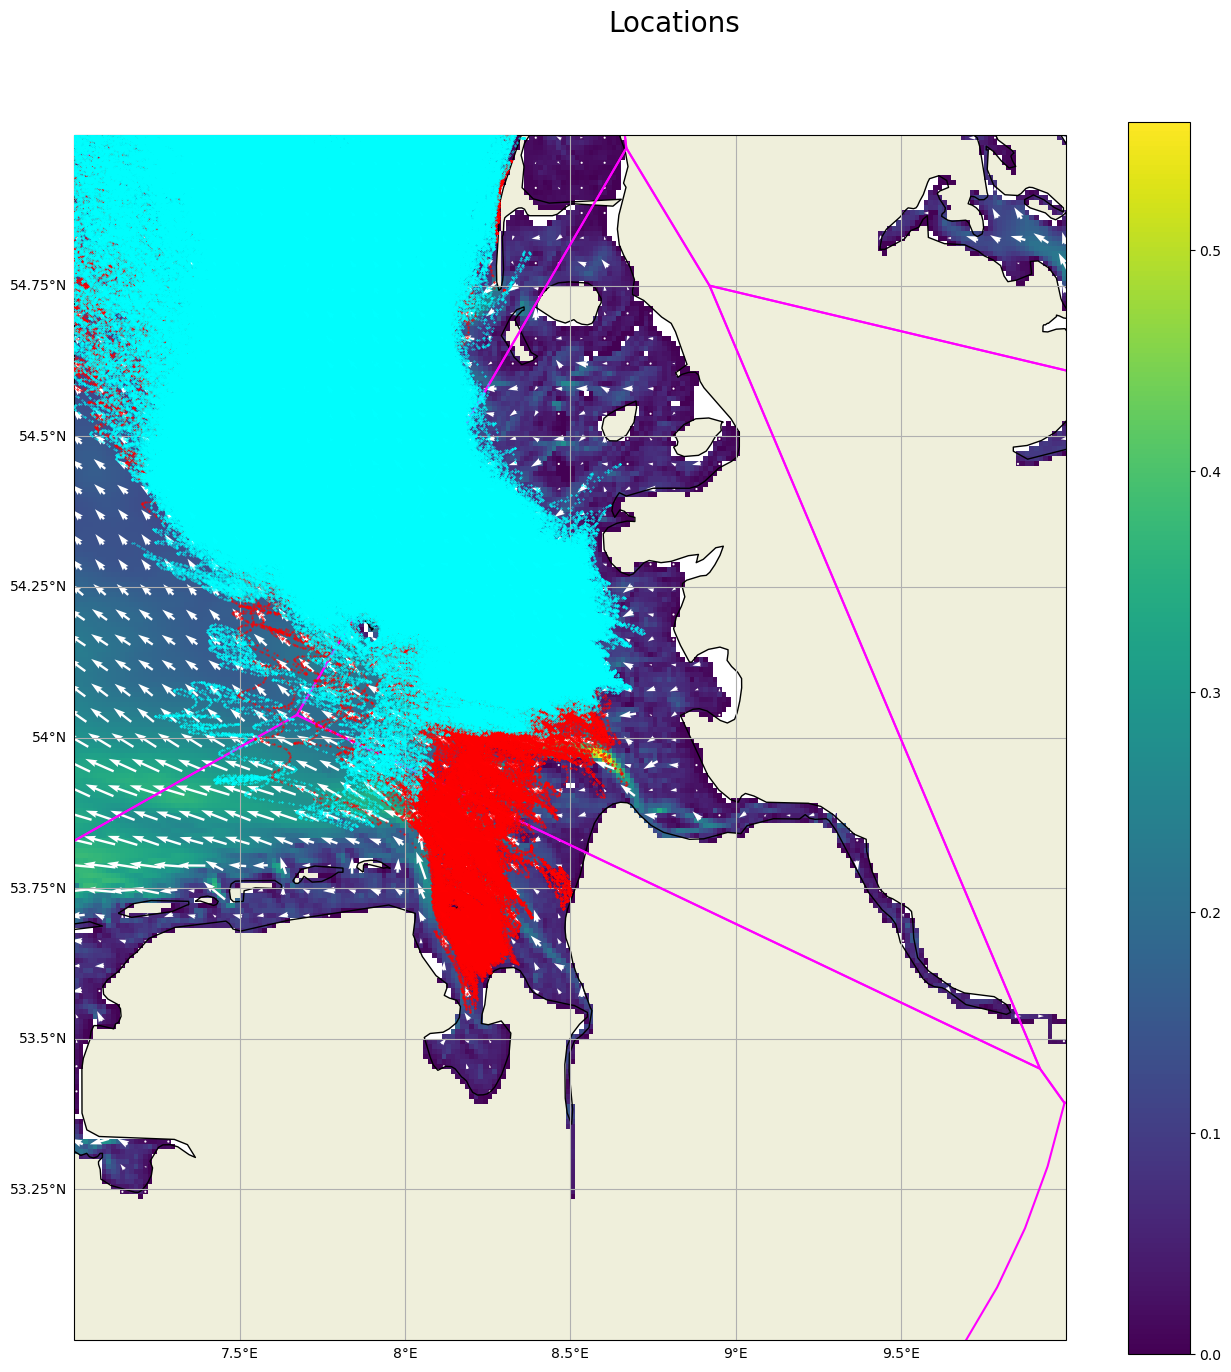

In [112]:
fig = plt.figure(figsize=mapsize)
fig.suptitle("Locations", size=suptitle_size, y=0.95)
ax_map = fig.add_subplot(projection=map_projection)
basemap(ax_map, extent)
abs_current.plot(ax=ax_map)
current.isel(lon=slice(None, None, 5), lat=slice(None, None, 5)).plot.quiver(x='lon', y='lat', u='uvel', v='vvel', color='white')
trajectory_WH02_far.plot.scatter(x='lon', y='lat', color='red', s=0.1, ax=ax_map, zorder=10)
trajectory_SK02_far.plot.scatter(x='lon', y='lat', color='cyan', s=0.1, ax=ax_map, zorder=10)
voronoi_polygons_moved.geometry.boundary.plot(color='magenta', ax=ax_map)
plt.show()